# pandas, EDA, and Merging Datasets — Week 3 In-Class Exercise (Answer Key)

Solutions for `week3_in_class_exercise.ipynb`.

## Setup (provided)

Run these cells as-is — they load and clean the three datasets, same as we did together.

### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the csv datasets

In [2]:
passengers = 'https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/datafiles-titanic.csv'
meals = 'https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/titanic_restaurant.csv'
luggage = 'https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/titanic_luggage.csv'

In [3]:
passengers_df = pd.read_csv(passengers)
meals_df = pd.read_csv(meals)
luggage_df = pd.read_csv(luggage)

### Clean up work

In [4]:
passengers_df.rename(columns={
    "sibsp": "siblings_spouse",
    "parch": "parents_children"
}, inplace=True)

In [5]:
class_order = ["First", "Second", "Third"]

passengers_df["class"] = pd.Categorical(
    passengers_df["class"],
    categories=class_order,
    ordered=True
)

## 1. Get to know the new tables

`passenger_id` is a UUID (Universally Unique Identifier) — it's the **primary key** in `passengers_df` (each passenger appears exactly once) and a **foreign key** in `meals_df` and `luggage_df` (it can appear many times, once per meal or bag).

1. Look at `.head()` and `.shape` for `meals_df` and `luggage_df`.
2. Use `.nunique()` on the `passenger_id` column of each of the three DataFrames. How many *unique* passengers appear in each table?
3. **Discuss:** based on the nunique() counts, does every passenger have at least one luggage record? Does every passenger have at least one meal record?

In [6]:
display(meals_df.head())
print(meals_df.shape)

display(luggage_df.head())
print(luggage_df.shape)

,passenger_id,restaurant_name,date,meal_type,meal_time
0,af1089fa-c928-4719-94ec-4bdb0aa90e8a,Third-Class Dining Room,1912-04-10,fish,breakfast
1,af1089fa-c928-4719-94ec-4bdb0aa90e8a,Third-Class Dining Room,1912-04-13,fish,breakfast
2,af1089fa-c928-4719-94ec-4bdb0aa90e8a,Third-Class Dining Room,1912-04-13,fish,dinner
3,5f616a6d-f338-4360-9d7b-3b92196dd350,First-Class Dining Saloon,1912-04-10,meat,breakfast
4,5f616a6d-f338-4360-9d7b-3b92196dd350,The Ritz,1912-04-10,poultry,dinner


(4288, 5)


,passenger_id,bag_number,bag_type,weight_kgs
0,af1089fa-c928-4719-94ec-4bdb0aa90e8a,1,duffel_bag,23.0
1,af1089fa-c928-4719-94ec-4bdb0aa90e8a,2,small_suitcase,11.1
2,5f616a6d-f338-4360-9d7b-3b92196dd350,1,suitcase,43.7
3,5f616a6d-f338-4360-9d7b-3b92196dd350,2,hat_box,18.8
4,5f616a6d-f338-4360-9d7b-3b92196dd350,3,wardrobe_trunk,45.2


(2036, 4)


In [7]:
print(passengers_df["passenger_id"].nunique())
print(meals_df["passenger_id"].nunique())
print(luggage_df["passenger_id"].nunique())

891
765
891


*Discussion:* `luggage_df` has 891 unique `passenger_id`s -- the same as `passengers_df` -- so every passenger has at least one luggage record. `meals_df` only has 765 unique `passenger_id`s, so 126 passengers have no meal record at all.

## 2. Merge luggage records with passenger info

Now let's follow the merge flow from lecture: start from `luggage_df` (the "many" side of the relationship) and merge passenger info onto it.

1. Merge `luggage_df` (left table) with `passengers_df` (right table), joining on `passenger_id`, using a left join (Hint: `luggage_df.merge(passengers_df, on="passenger_id", how="left")`). Save it as `luggage_with_passengers_df`.
2. Look at `.head()` of `luggage_with_passengers_df`. **Discuss:** is this a useful view? Notice how the same passenger's info (`age`, `fare`, `class`, etc.) repeats across multiple rows — why does that happen?
3. Use `luggage_with_passengers_df` to answer a real question: does baggage weight differ by embarkation town? Group by `embark_town` and take the mean of `weight_kgs` (Hint: `.groupby("embark_town")["weight_kgs"].mean()`).

In [8]:
luggage_with_passengers_df = luggage_df.merge(passengers_df, on="passenger_id", how="left")
luggage_with_passengers_df.head()

,passenger_id,bag_number,bag_type,weight_kgs,survived,sex,age,siblings_spouse,parents_children,fare,class,embark_town
0,af1089fa-c928-4719-94ec-4bdb0aa90e8a,1,duffel_bag,23.0,0,male,22.0,1,0,7.2500,Third,Southampton
1,af1089fa-c928-4719-94ec-4bdb0aa90e8a,2,small_suitcase,11.1,0,male,22.0,1,0,7.2500,Third,Southampton
2,5f616a6d-f338-4360-9d7b-3b92196dd350,1,suitcase,43.7,1,female,38.0,1,0,71.2833,First,Cherbourg
3,5f616a6d-f338-4360-9d7b-3b92196dd350,2,hat_box,18.8,1,female,38.0,1,0,71.2833,First,Cherbourg
4,5f616a6d-f338-4360-9d7b-3b92196dd350,3,wardrobe_trunk,45.2,1,female,38.0,1,0,71.2833,First,Cherbourg


In [9]:
display(luggage_with_passengers_df.groupby("embark_town")["weight_kgs"].mean())
display(luggage_with_passengers_df.groupby("embark_town")["class"].value_counts())

embark_town
Cherbourg      28.377019
Queenstown     16.469841
Southampton    22.952361
Name: weight_kgs, dtype: float64

embark_town  class 
Cherbourg    First     344
             Third      99
             Second     40
Queenstown   Third     110
             First       9
             Second      7
Southampton  Third     525
             First     519
             Second    383
Name: count, dtype: int64

*Discussion:* Not really, as a passenger-level view -- `luggage_df` has multiple rows per passenger (one per bag), so merging passenger info onto it repeats the same `age`, `fare`, and `class` values across every bag belonging to that passenger. This is a *bag-level* table, which is exactly what makes it useful for bag-level questions (like comparing average weight by `embark_town` in step 3), even though it's redundant for passenger-level questions.

## 3. Summarizing luggage and meals, then merging back onto passengers

A row-per-bag table isn't very useful for passenger-level analysis. Let's summarize it first, the way we did in lecture.

1. Group `luggage_df` by `passenger_id` and use `.size().reset_index(name="luggage_count")` to count how many bags each passenger brought. Save it as `luggage_counts_df`.
2. Group `luggage_df` by `passenger_id` again, but this time use `["weight_kgs"].sum().reset_index(name="total_luggage_weight")` to get each passenger's total baggage weight. Save it as `luggage_weight_df`.
3. Merge both `luggage_counts_df` and `luggage_weight_df` onto `passengers_df` (on `passenger_id`, `how="left"`), overwriting `passengers_df`.
4. Now do the same for `meals_df`: group by `passenger_id` and count how many meal records each passenger has (Hint: same `.size().reset_index(name=...)` pattern). Call it `meal_counts_df`, then merge it onto `passengers_df`.
5. Confirm everything worked with `.info()` and `.head()` on `passengers_df`.

In [10]:
luggage_counts_df = luggage_df.groupby("passenger_id").size().reset_index(name="luggage_count")
luggage_counts_df

,passenger_id,luggage_count
0,001c43f2-cc62-405f-bc6b-32fe01ac690e,4
1,005eeee0-731c-4140-8173-7e320708fc8b,2
2,0095bd9e-f724-4ea0-b36c-14c422372fa6,1
3,010ed1a2-8f40-41c0-9440-e4eaa68c23bf,1
4,015ef17d-8360-430a-97b2-81d13fcf1674,2
...,...,...
886,fcf07c16-653f-49f8-b41d-848d654433fb,2
887,fda40ec4-cff3-447e-a12d-f2391ac2a016,3
888,fe237248-3145-49c3-873a-23103a548d48,3
889,ff4c5bd2-a58f-4d1b-9ba9-98c963e6a1f1,1


In [11]:
luggage_weight_df = luggage_df.groupby("passenger_id")["weight_kgs"].sum().reset_index(name="total_luggage_weight")
luggage_weight_df

,passenger_id,total_luggage_weight
0,001c43f2-cc62-405f-bc6b-32fe01ac690e,143.3
1,005eeee0-731c-4140-8173-7e320708fc8b,36.0
2,0095bd9e-f724-4ea0-b36c-14c422372fa6,8.1
3,010ed1a2-8f40-41c0-9440-e4eaa68c23bf,23.2
4,015ef17d-8360-430a-97b2-81d13fcf1674,31.3
...,...,...
886,fcf07c16-653f-49f8-b41d-848d654433fb,29.6
887,fda40ec4-cff3-447e-a12d-f2391ac2a016,70.6
888,fe237248-3145-49c3-873a-23103a548d48,101.8
889,ff4c5bd2-a58f-4d1b-9ba9-98c963e6a1f1,6.4


In [12]:
passengers_df = passengers_df.merge(luggage_counts_df, on="passenger_id", how="left")
passengers_df = passengers_df.merge(luggage_weight_df, on="passenger_id", how="left")

In [13]:
meal_counts_df = meals_df.groupby("passenger_id").size().reset_index(name="meal_count")
passengers_df = passengers_df.merge(meal_counts_df, on="passenger_id", how="left")

In [14]:
passengers_df.info()
display(passengers_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   passenger_id          891 non-null    str     
 1   survived              891 non-null    int64   
 2   sex                   891 non-null    str     
 3   age                   714 non-null    float64 
 4   siblings_spouse       891 non-null    int64   
 5   parents_children      891 non-null    int64   
 6   fare                  891 non-null    float64 
 7   class                 891 non-null    category
 8   embark_town           889 non-null    str     
 9   luggage_count         891 non-null    int64   
 10  total_luggage_weight  891 non-null    float64 
 11  meal_count            765 non-null    float64 
dtypes: category(1), float64(4), int64(4), str(3)
memory usage: 77.7 KB


,passenger_id,survived,sex,age,siblings_spouse,parents_children,fare,class,embark_town,luggage_count,total_luggage_weight,meal_count
0,af1089fa-c928-4719-94ec-4bdb0aa90e8a,0,male,22.0,1,0,7.2500,Third,Southampton,2,34.1,3.0
1,5f616a6d-f338-4360-9d7b-3b92196dd350,1,female,38.0,1,0,71.2833,First,Cherbourg,3,107.7,13.0
2,34ad8431-f090-40d0-a1c9-50fe2cb39979,1,female,26.0,0,0,7.9250,Third,Southampton,2,32.8,2.0
3,3bcdceb3-f1dd-4ef2-a9dc-089c13f54a27,1,female,35.0,1,0,53.1000,First,Southampton,4,139.8,9.0
4,0ee5b915-66c7-42d4-ba2d-5c0703633ccc,0,male,35.0,0,0,8.0500,Third,Southampton,1,22.7,2.0


## 4. Numeric relationships: scatter plots and correlation

1. Make a scatter plot of `total_luggage_weight` (x) vs `fare` (y) using `.plot.scatter()`.
2. Compute correlation coefficients for a few different pairs of columns using `.corr()`: `total_luggage_weight` vs `fare`, `fare` vs `age`, and `age` vs `class` (Hint: `class` is categorical, so convert it to numeric codes first with `passengers_df["class"].cat.codes`). **Discuss:** based on the scatter plot and these correlation values, which relationships look meaningful and which don't?
3. Create a new column `class_code` on `passengers_df` (Hint: `passengers_df["class_code"] = passengers_df["class"].cat.codes`), then compute the full correlation matrix with `passengers_df.corr(numeric_only=True)` — since `class_code` is now a real numeric column, it's included automatically. Save the result as `correlation_matrix`.
4. Visualize `correlation_matrix` — which now includes `class_code` alongside the other numeric columns — as a heatmap with `sns.heatmap()` (Hint: `annot=True, cmap='RdBu_r', center=0`).

<Axes: xlabel='total_luggage_weight', ylabel='fare'>

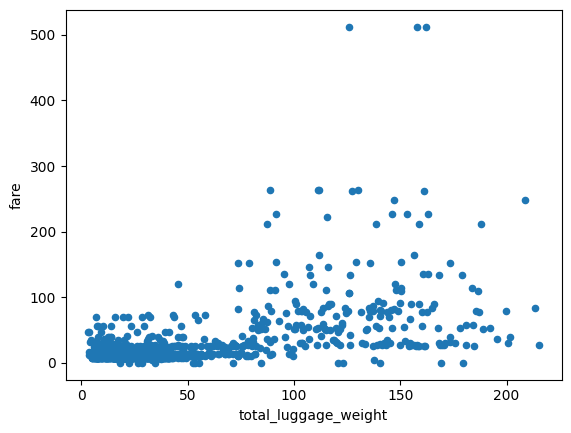

In [15]:
passengers_df.plot.scatter(x="total_luggage_weight", y="fare")

In [16]:
print(passengers_df["total_luggage_weight"].corr(passengers_df["fare"]))
print(passengers_df["fare"].corr(passengers_df["age"]))
print(passengers_df["age"].corr(passengers_df["class"].cat.codes))

0.5359866326371459
0.09606669176903891
-0.3692260153155172


In [17]:
passengers_df["class_code"] = passengers_df["class"].cat.codes

correlation_matrix = passengers_df.corr(numeric_only=True)
correlation_matrix

,survived,age,siblings_spouse,parents_children,fare,luggage_count,total_luggage_weight,meal_count,class_code
survived,1.000000,-0.077221,-0.035322,0.081629,0.257307,0.248998,0.280359,0.306149,-0.338481
age,-0.077221,1.000000,-0.308247,-0.189119,0.096067,0.401507,0.397982,0.393429,-0.369226
siblings_spouse,-0.035322,-0.308247,1.000000,0.414838,0.159651,-0.110157,-0.101539,-0.081722,0.083081
parents_children,0.081629,-0.189119,0.414838,1.000000,0.216225,-0.088600,-0.073866,-0.031632,0.018443
fare,0.257307,0.096067,0.159651,0.216225,1.000000,0.497518,0.535987,0.524209,-0.549500
luggage_count,0.248998,0.401507,-0.110157,-0.088600,0.497518,1.000000,0.940855,0.814903,-0.851028
total_luggage_weight,0.280359,0.397982,-0.101539,-0.073866,0.535987,0.940855,1.000000,0.856416,-0.890670
meal_count,0.306149,0.393429,-0.081722,-0.031632,0.524209,0.814903,0.856416,1.000000,-0.935634
class_code,-0.338481,-0.369226,0.083081,0.018443,-0.549500,-0.851028,-0.890670,-0.935634,1.000000


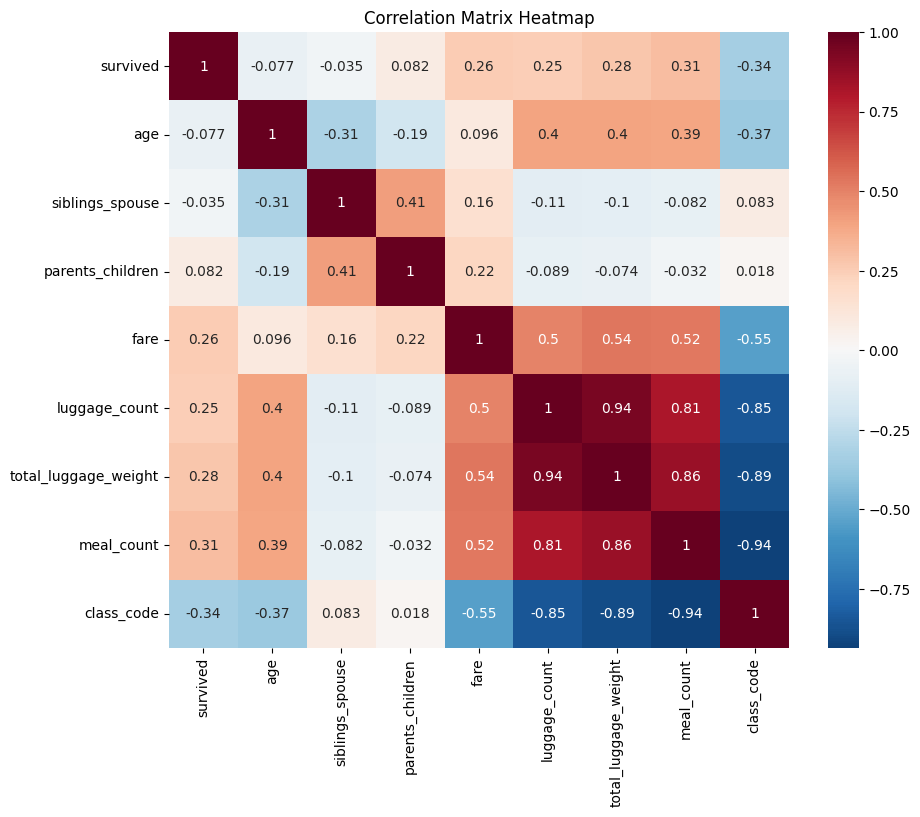

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

## 5. Categorical relationships: crosstabs

1. Build a crosstab of `sex` (rows) by `class` (columns) with `margins=True` to add row/column totals.
2. Rebuild it three more times, using `normalize="all"`, `normalize="index"`, and `normalize="columns"`. **Discuss:** in one sentence each, what question does each of the three answer?
3. Plot the `sex` by `class` crosstab (counts, no normalize) as a bar chart with `.plot.bar()`.
4. Build a **nested** crosstab of `[sex, class]` (rows) by `survived` (columns) — pass a list in brackets for the index (Hint: `pd.crosstab([passengers_df['sex'], passengers_df['class']], passengers_df['survived'])`). **Discuss:** what new pattern (if any) do you see once you add class as a second row variable?

In [19]:
pd.crosstab(passengers_df["sex"], passengers_df["class"], margins=True)

class,First,Second,Third,All
sex,,,,
female,94,76,144,314
male,122,108,347,577
All,216,184,491,891


In [20]:
display((pd.crosstab(passengers_df["sex"], passengers_df["class"], normalize="all") * 100).round(1))
display((pd.crosstab(passengers_df["sex"], passengers_df["class"], normalize="index") * 100).round(1))
display((pd.crosstab(passengers_df["sex"], passengers_df["class"], normalize="columns") * 100).round(1))

class,First,Second,Third
sex,,,
female,10.5,8.5,16.2
male,13.7,12.1,38.9


class,First,Second,Third
sex,,,
female,29.9,24.2,45.9
male,21.1,18.7,60.1


class,First,Second,Third
sex,,,
female,43.5,41.3,29.3
male,56.5,58.7,70.7


*Discussion:* `normalize="all"` answers "what share of *all* passengers fall in this sex/class combination?" `normalize="index"` (row) answers "within this sex, how are passengers split across classes?" `normalize="columns"` answers "within this class, how are passengers split by sex?"

<Axes: title={'center': 'Passengers by Sex and Class'}, xlabel='sex'>

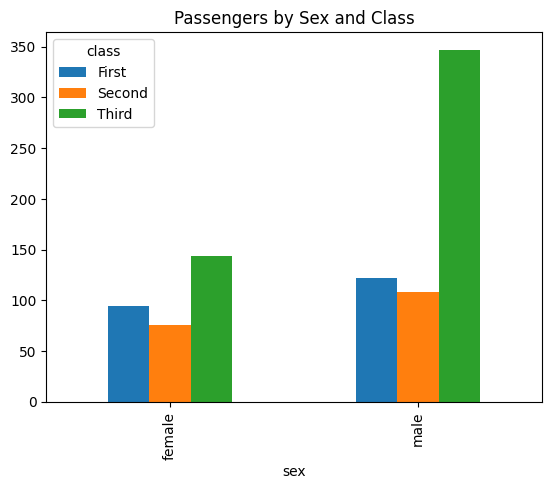

In [21]:
pd.crosstab(passengers_df["sex"], passengers_df["class"]).plot.bar(title="Passengers by Sex and Class")

In [22]:
pd.crosstab([passengers_df["sex"], passengers_df["class"]], passengers_df["survived"])

survived         0   1
sex    class          
female First     3  91
       Second    6  70
       Third    72  72
male   First    77  45
       Second   91  17
       Third   300  47

*Discussion:* Sex alone (from Week 2) already showed a big survival gap, but nesting class underneath it shows the gap isn't uniform -- almost all First and Second class women survived, while Third class women were roughly a coin flip. Men show the opposite pattern: even First class men had a much lower survival rate than any group of women, though First class men still did better than Second or Third class men.

## 6. Mixing categorical and numeric: `.groupby().agg()` and `pd.pivot_table()`

1. Group `passengers_df` by `class` and compute, in a single `.agg()` call: the count and mean of `age`, the mean of `fare`, and the mean of `luggage_count`. Round the result to 1 decimal.
2. Now build a `.groupby("class").agg(...)` call where **each column gets a different aggregation function** — e.g. `fare` gets `"mean"` and `"max"`, `age` gets `"median"`, `luggage_count` gets `"sum"` (Hint: pass a dictionary like `{"fare": ["mean", "max"], "age": "median", "luggage_count": "sum"}`).
3. Reproduce the same summary from step 2 using `pd.pivot_table()` instead of `.groupby().agg()` (Hint: `pd.pivot_table(passengers_df, index="class", values=[...], aggfunc=...)`).

In [23]:
passengers_df.groupby("class").agg({
    "age": ["count", "mean"],
    "fare": "mean",
    "luggage_count": "mean"
}).round(1)

age        fare luggage_count
       count  mean  mean          mean
class                                 
First    186  38.2  84.2           4.0
Second   173  29.9  20.7           2.3
Third    355  25.1  13.7           1.5

In [24]:
passengers_df.groupby("class").agg({
    "fare": ["mean", "max"],
    "age": "median",
    "luggage_count": "sum"
})

fare              age luggage_count
             mean       max median           sum
class                                           
First   84.154687  512.3292   37.0           872
Second  20.662183   73.5000   29.0           430
Third   13.675550   69.5500   24.0           734

In [25]:
pd.pivot_table(
    passengers_df,
    index="class",
    values=["age", "fare", "luggage_count"],
    aggfunc={"age": "median", "fare": ["mean", "max"], "luggage_count": "sum"}
)

age      fare            luggage_count
       median       max       mean           sum
class                                           
First    37.0  512.3292  84.154687           872
Second   29.0   73.5000  20.662183           430
Third    24.0   69.5500  13.675550           734

## 7. Helper functions: `.nlargest()`, `.nsmallest()`, `.rank()`

1. Find the 5 passengers with the highest `fare` using `.nlargest(5, "fare", keep="all")` (`keep="all"` keeps every passenger tied for 5th place, even if that means returning more than 5 rows).
2. Find the 5 youngest passengers using `.nsmallest(5, "age")`.
3. Create a new column `fare_ranked` that ranks passengers by `fare` using `.rank(method="min", ascending=False)`, then use `.sort_values("fare_ranked")` to view `passenger_id`, `fare`, and `fare_ranked` side by side (Hint: `passengers_df.sort_values("fare_ranked")[["passenger_id", "fare", "fare_ranked"]]`).

In [26]:
passengers_df.nlargest(5, "fare", keep="all")

,passenger_id,survived,sex,age,siblings_spouse,parents_children,fare,class,embark_town,luggage_count,total_luggage_weight,meal_count,class_code
258,5ad90b25-4c54-48f8-b3c7-b6376e96d4ee,1,female,35.0,0,0,512.3292,First,Cherbourg,5,158.0,14.0,0
679,51901a0f-b882-4ce5-9f1d-df726dfc52cb,1,male,36.0,0,1,512.3292,First,Cherbourg,4,125.7,12.0,0
737,939c7a36-01ef-47e4-a1a4-fa6baee95cf7,1,male,35.0,0,0,512.3292,First,Cherbourg,5,161.9,11.0,0
27,827a11d9-04e9-4074-962b-65339f16ab54,0,male,19.0,3,2,263.0000,First,Southampton,3,111.3,14.0,0
88,7b102a9b-d25d-4eba-b7d0-d3c29129515e,1,female,23.0,3,2,263.0000,First,Southampton,3,89.0,14.0,0
341,c52f3111-c5bf-49fe-8958-ef1f4e88eaef,1,female,24.0,3,2,263.0000,First,Southampton,4,130.2,11.0,0
438,0b9f6b66-463a-4ba3-b490-400f1511dd5b,0,male,64.0,1,4,263.0000,First,Southampton,3,111.9,14.0,0


In [27]:
passengers_df.nsmallest(5, "age")

,passenger_id,survived,sex,age,siblings_spouse,parents_children,fare,class,embark_town,luggage_count,total_luggage_weight,meal_count,class_code
803,6bbb5b9c-6035-4801-82de-703703d9ba88,1,male,0.42,0,1,8.5167,Third,Cherbourg,1,12.4,NaN,2
755,434da032-7067-4f9f-aa54-851bf502d1e7,1,male,0.67,1,1,14.5000,Second,Southampton,2,18.3,NaN,1
469,ef387ca4-6e85-45e7-99cd-5ad256b18f15,1,female,0.75,2,1,19.2583,Third,Cherbourg,1,6.9,1.0,2
644,94b670ba-5448-436e-bb94-d6c0342ee5f2,1,female,0.75,2,1,19.2583,Third,Cherbourg,1,14.3,2.0,2
78,e0aaeef1-ff54-4785-b81c-c6f98dd52bd6,1,male,0.83,0,2,29.0000,Second,Southampton,1,21.1,1.0,1


In [28]:
passengers_df["fare_ranked"] = passengers_df["fare"].rank(method="min", ascending=False)
passengers_df.sort_values("fare_ranked")[["passenger_id", "fare", "fare_ranked"]]

,passenger_id,fare,fare_ranked
737,939c7a36-01ef-47e4-a1a4-fa6baee95cf7,512.3292,1.0
258,5ad90b25-4c54-48f8-b3c7-b6376e96d4ee,512.3292,1.0
679,51901a0f-b882-4ce5-9f1d-df726dfc52cb,512.3292,1.0
88,7b102a9b-d25d-4eba-b7d0-d3c29129515e,263.0000,4.0
341,c52f3111-c5bf-49fe-8958-ef1f4e88eaef,263.0000,4.0
...,...,...,...
597,96c2f5a2-00f3-4c72-8dd2-8f0b0c3f5eb6,0.0000,877.0
277,5805c018-847b-4670-80e5-a136859ba172,0.0000,877.0
271,79d2c4ba-2381-4b93-982b-8bdeccfc9632,0.0000,877.0
674,2bdd9fd6-4c76-410c-bb7c-652fea9c309f,0.0000,877.0


## 8. Missing data after merging

1. Run `.isna().sum()` on `passengers_df`. Which columns now have missing values that *didn't* before we merged?
2. **Discuss:** for a passenger with `NaN` in `luggage_count` or `meal_count`, what does that `NaN` actually mean? Is it "unknown," or is it something else?
3. Based on your answer to step 2, fill the missing values in `meal_count` with `0` (Hint: `.fillna(0)`).

In [29]:
passengers_df.isna().sum()

passenger_id              0
survived                  0
sex                       0
age                     177
siblings_spouse           0
parents_children          0
fare                      0
class                     0
embark_town               2
luggage_count             0
total_luggage_weight      0
meal_count              126
class_code                0
fare_ranked               0
dtype: int64

*Discussion:* `luggage_count` and `total_luggage_weight` have no missing values, since every passenger had at least one luggage record. `meal_count` has 126 missing values -- one for every passenger who had no row in `meals_df`. For those passengers, `NaN` doesn't mean "unknown" the way missing `age` does -- it means the count is genuinely zero, we just don't have a row to count.

In [30]:
passengers_df["meal_count"] = passengers_df["meal_count"].fillna(0)

## 9. Outliers with the IQR method

We'll use `fare` to practice identifying and handling outliers.

1. Compute `Q1` (25th percentile) and `Q3` (75th percentile) of `fare` using `.quantile()`, then compute `IQR = Q3 - Q1`.
2. Compute the outlier boundaries: `lower_bound = Q1 - 1.5 * IQR` and `upper_bound = Q3 + 1.5 * IQR`.
3. Count how many passengers have a `fare` above `upper_bound` (Hint: boolean mask + `.sum()`). Are there any below `lower_bound`?

In [31]:
Q1 = passengers_df["fare"].quantile(0.25)
Q3 = passengers_df["fare"].quantile(0.75)
IQR = Q3 - Q1
print(round(Q1, 2), round(Q3, 2), round(IQR, 2))

7.91 31.0 23.09


In [32]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(round(lower_bound, 2), round(upper_bound, 2))

-26.72 65.63


In [33]:
# lower_bound is negative, so no fares can fall below it -- fares can't be negative
print((passengers_df["fare"] > upper_bound).sum())
print((passengers_df["fare"] < lower_bound).sum())

116
0


## 10. Dummy variables and an expanded correlation heatmap

`.corr()` only works on numeric columns, so categorical columns like `sex`, `class`, and `embark_town` were left out of `correlation_matrix` above. One-hot encoding turns them into 0/1 columns so they can join the correlation analysis.

1. Use `pd.get_dummies()` to one-hot encode `sex`, `class`, and `embark_town` in `passengers_df`. First drop the `passenger_id` column, since it's just an identifier and would break `.corr()` later (Hint: `pd.get_dummies(passengers_df.drop(columns="passenger_id"), columns=["sex", "class", "embark_town"])`). Save the result as `passengers_dummies`.
2. Compute the correlation matrix of `passengers_dummies` and save it as `dummies_correlation_matrix`.
3. Look at just the `survived` column of `dummies_correlation_matrix` (Hint: `dummies_correlation_matrix["survived"].sort_values()`). **Discuss:** which categories correlate most strongly (positive or negative) with survival? Does this match what you already found in Week 2's survival analysis?

In [34]:
passengers_dummies = pd.get_dummies(
    passengers_df.drop(columns="passenger_id"), columns=["sex", "class", "embark_town"]
)
passengers_dummies.head()

,survived,age,siblings_spouse,parents_children,fare,luggage_count,total_luggage_weight,meal_count,class_code,fare_ranked,sex_female,sex_male,class_First,class_Second,class_Third,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,22.0,1,0,7.2500,2,34.1,3.0,2,809.0,False,True,False,False,True,False,False,True
1,1,38.0,1,0,71.2833,3,107.7,13.0,0,103.0,True,False,True,False,False,True,False,False
2,1,26.0,0,0,7.9250,2,32.8,2.0,2,651.0,True,False,False,False,True,False,False,True
3,1,35.0,1,0,53.1000,4,139.8,9.0,0,142.0,True,False,True,False,False,False,False,True
4,0,35.0,0,0,8.0500,1,22.7,2.0,2,607.0,False,True,False,False,True,False,False,True


In [35]:
dummies_correlation_matrix = passengers_dummies.corr(numeric_only=True)
dummies_correlation_matrix

,survived,age,siblings_spouse,parents_children,fare,luggage_count,total_luggage_weight,meal_count,class_code,fare_ranked,sex_female,sex_male,class_First,class_Second,class_Third,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
survived,1.000000,-0.077221,-0.035322,0.081629,0.257307,0.248998,0.280359,0.296233,-0.338481,-0.322046,0.543351,-0.543351,0.285904,0.093349,-0.322308,0.168240,0.003650,-0.155660
age,-0.077221,1.000000,-0.308247,-0.189119,0.096067,0.401507,0.397982,0.416808,-0.369226,-0.116334,-0.093254,0.093254,0.348941,0.006954,-0.312271,0.036261,-0.022405,-0.032523
siblings_spouse,-0.035322,-0.308247,1.000000,0.414838,0.159651,-0.110157,-0.101539,-0.102194,0.083081,-0.357585,0.114631,-0.114631,-0.054582,-0.055932,0.092548,-0.059528,-0.026354,0.070941
parents_children,0.081629,-0.189119,0.414838,1.000000,0.216225,-0.088600,-0.073866,-0.059478,0.018443,-0.366020,0.245489,-0.245489,-0.017633,-0.000734,0.015790,-0.011069,-0.081228,0.063036
fare,0.257307,0.096067,0.159651,0.216225,1.000000,0.497518,0.535987,0.519454,-0.549500,-0.639490,0.182333,-0.182333,0.591711,-0.118557,-0.413333,0.269335,-0.117216,-0.166603
luggage_count,0.248998,0.401507,-0.110157,-0.088600,0.497518,1.000000,0.940855,0.809639,-0.851028,-0.552739,0.090292,-0.090292,0.819348,0.021883,-0.723763,0.235100,-0.164950,-0.109007
total_luggage_weight,0.280359,0.397982,-0.101539,-0.073866,0.535987,0.940855,1.000000,0.856076,-0.890670,-0.601680,0.107058,-0.107058,0.881113,-0.027064,-0.737144,0.264221,-0.172575,-0.131570
meal_count,0.296233,0.416808,-0.102194,-0.059478,0.519454,0.809639,0.856076,1.000000,-0.922530,-0.624849,0.122800,-0.122800,0.850332,0.103876,-0.817190,0.252528,-0.205022,-0.098241
class_code,-0.338481,-0.369226,0.083081,0.018443,-0.549500,-0.851028,-0.890670,-0.922530,1.000000,0.700150,-0.131900,0.131900,-0.885924,-0.188432,0.916673,-0.243292,0.221009,0.081720
fare_ranked,-0.322046,-0.116334,-0.357585,-0.366020,-0.639490,-0.552739,-0.601680,-0.624849,0.700150,1.000000,-0.257172,0.257172,-0.642304,-0.085297,0.622832,-0.199360,0.233096,0.035085


In [36]:
dummies_correlation_matrix["survived"].sort_values()

sex_male                  -0.543351
class_code                -0.338481
class_Third               -0.322308
fare_ranked               -0.322046
embark_town_Southampton   -0.155660
age                       -0.077221
siblings_spouse           -0.035322
embark_town_Queenstown     0.003650
parents_children           0.081629
class_Second               0.093349
embark_town_Cherbourg      0.168240
luggage_count              0.248998
fare                       0.257307
total_luggage_weight       0.280359
class_First                0.285904
meal_count                 0.296233
sex_female                 0.543351
survived                   1.000000
Name: survived, dtype: float64

*Discussion:* `sex_female` (+0.54) and `sex_male` (-0.54) remain by far the strongest correlates of survival -- being female is associated with a much higher survival rate, matching the big gender gap found in Week 2. After sex, `class_Third` (-0.32) and `class_First` (+0.29) reproduce the same first-class advantage / third-class disadvantage seen in Week 2's class breakdown. The luggage- and meal-related columns (`meal_count`, `total_luggage_weight`, `fare`, `luggage_count`) also correlate positively with survival, but these are more likely proxies for wealth/class than a direct effect of their own.

## 11. Putting it together: feature engineering and survival

1. Create `family_size` = `siblings_spouse + parents_children + 1`.
2. Create `is_alone` = `True` if `family_size == 1`, else `False`.
3. Compute the survival rate (as a %) for `is_alone` vs. not, using a crosstab or groupby normalized to a percent, the same way you did in Week 2. **Discuss:** does traveling alone matter?
4. **Optional:** does `luggage_count` relate to survival? Create a crosstab or groupby of `luggage_count` (or a binned version of it) against `survived`, normalized by row. Is there a pattern, or is this more likely a spurious correlation (like the Nicolas Cage example from lecture)?

In [37]:
passengers_df["family_size"] = passengers_df["siblings_spouse"] + passengers_df["parents_children"] + 1

In [38]:
passengers_df["is_alone"] = passengers_df["family_size"] == 1

In [39]:
(pd.crosstab(passengers_df["is_alone"], passengers_df["survived"], normalize="index") * 100).round(1)

survived,0,1
is_alone,,
False,49.4,50.6
True,69.6,30.4


*Discussion:* Passengers traveling alone had a notably lower survival rate (30.4%) than those traveling with family (50.6%) -- traveling alone does appear to matter, likely because family groups could look out for each other during the evacuation, or because solo travelers skewed toward lower-fare, lower-class tickets.

In [40]:
(pd.crosstab(passengers_df["luggage_count"], passengers_df["survived"], normalize="index") * 100).round(1)

survived,0,1
luggage_count,,
1,70.7,29.3
2,71.4,28.6
3,45.0,55.0
4,32.3,67.7
5,42.5,57.5


*Discussion:* Survival rises sharply with luggage count (roughly 29% for 1-2 bags vs. 55-68% for 3-5 bags), but this is almost certainly a proxy relationship rather than a causal one -- passengers who could bring more luggage were more likely traveling in First or Second class with higher fares, and it's that underlying wealth/class effect driving survival, not the luggage itself.